<a href="https://colab.research.google.com/github/zhilyaevaviktorija/machine_learning/blob/main/lectures/Lecture_4_(25_02_26)_%22w2v_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Word2Vec** - алгоритм для создания векторных представлений слов на основе их дистрибутивных свойств

**Две архитектуры:**
- **CBOW (Continuous Bag-of-Words)**: предсказывает центральное слово по контексту
- **Skip-Gram**: предсказывает контекстные слова по центральному слову

**Ключевые параметры:**
- `vector_size`: размерность векторов
- `window`: размер контекстного окна
- `min_count`: минимальная частота слова
- `workers`: количество ядер для обучения
- `sg`: архитектура (0 = CBOW, 1 = Skip-Gram)

In [ ]:
!pip install nltk # Natural Language Toolkit — главная библиотека для обработки естественного языка на Python
import nltk
from nltk.corpus import brown
from IPython.display import clear_output

nltk.download('brown')    # загружаем корпус Brown
nltk.download('punkt')    # загружаем токенизатор (для разбиения на предложения)
clear_output()            # очищаем вывод, чтобы убрать лишние сообщения о загрузке

sentences = brown.sents() # получаем список предложений

print(f"Общее количество предложений: {len(sentences):,}")
print(f"Общее количество слов: {len(brown.words()):,}")
print(f"Размер словаря: {len(set(brown.words())):,}")
print(f"Категории текстов: {brown.categories()}")

Общее количество предложений: 57,340
Общее количество слов: 1,161,192
Размер словаря: 56,057
Категории текстов: ['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']


### **Описание Brown Corpus:**
- **Первый компьютерный корпус английского языка** (1964)
- **500 текстов** по ~2000 слов каждый
- **Жанры**: новости, художественная литература, научные тексты
- **Сбалансированный** по жанрам и темам

### **Предобработка:**
- Использование `str.maketrans()` для удаления пунктуации
- Фильтрация слов длиной > 1 символа (убирает артикли "a" и т.д.)
- Минимальная длина предложения = 3 слова для задания контекста

In [ ]:
!pip install gensim

from gensim.models import Word2Vec
import string

# Предобработка с использованием готовых инструментов
def preprocess_text(sentences, sample_size=10000):
    processed_sentences = []

    # Создаем транслятор для удаления пунктуации
    translator = str.maketrans('', '', string.punctuation)

    for sentence in sentences[:sample_size]:
        # Приводим к нижнему регистру и удаляем пунктуацию
        cleaned = [word.lower().translate(translator) for word in sentence]

        # Убираем пустые строки и оставляем только слова
        words = [word for word in cleaned if word.isalpha() and len(word) > 1]

        # Фильтруем слишком короткие предложения
        if len(words) >= 3:  # Минимум 3 слова для контекста
            processed_sentences.append(words)

    return processed_sentences

# Обрабатываем предложения
processed_sentences = preprocess_text(sentences, sample_size=55000)
print(f"Обработано предложений: {len(processed_sentences):,}")
print(f"Пример обработанного предложения: {processed_sentences[150]}")

Обработано предложений: 52,357
Пример обработанного предложения: ['the', 'bills', 'defenders', 'were', 'mostly', 'smalltown', 'legislators', 'like', 'buchanan', 'of', 'dumas', 'eligio', 'kika', 'de', 'la', 'garza', 'of', 'mission', 'sam', 'collins', 'of', 'newton', 'and', 'joe', 'chapman', 'of', 'sulphur', 'springs']


In [ ]:
nltk.download('stopwords')

# Функция для удаления стоп слов
def remove_stopwords(sentences):
    """
    Удаляет стоп-слова из предложений
    """
    from nltk.corpus import stopwords

    # Загружаем стоп-слова для английского
    stop_words = set(stopwords.words('english'))
    print(stop_words)
    processed_sentences = []
    for sentence in sentences:
        # Убираем стоп-слова
        filtered_sentence = [word for word in sentence if word not in stop_words]
        processed_sentences.append(filtered_sentence)

    return processed_sentences

# Удаляем стоп-слова
sentences_without_stopwords = remove_stopwords(processed_sentences)

sentences_without_stopwords[150]

{"he'll", 'is', 'that', 'shouldn', "should've", 'they', 'ain', 'just', "you'd", 'same', 'no', 'o', 'very', 'd', 'other', 'didn', 'after', 'm', 'you', 'will', 'won', "haven't", 'hasn', 'further', 'your', 'be', 'does', 't', 'hers', 'ourselves', "wouldn't", 'if', 'was', "they've", 'my', 'as', 'i', "weren't", "we've", 'wasn', 'against', 'under', "we'd", 'can', "they're", 'myself', "it's", "wasn't", 'below', 'having', "don't", 'these', 'do', 'once', "won't", 'were', 'whom', 'but', 'has', "it'd", 'so', "you're", 'why', 'yourself', 'over', 'up', 'ma', "i'd", 'by', 'aren', 'who', 'have', "doesn't", "shan't", 'am', "i've", 'haven', 'because', 'down', 'all', 'few', 'should', 'yourselves', 'or', "didn't", 'doesn', 'we', 'he', 'needn', 'me', 'had', 've', 'at', 'of', 'doing', 'himself', "you'll", "isn't", 'for', 'couldn', 'its', 'through', 'how', "aren't", 'a', 'it', 'those', 'with', 'mustn', 'about', "i'm", 'she', 'while', 'her', 'our', "he'd", "we're", 'above', 'yours', 'y', 'isn', 'an', 'most', 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['bills',
 'defenders',
 'mostly',
 'smalltown',
 'legislators',
 'like',
 'buchanan',
 'dumas',
 'eligio',
 'kika',
 'de',
 'la',
 'garza',
 'mission',
 'sam',
 'collins',
 'newton',
 'joe',
 'chapman',
 'sulphur',
 'springs']

In [ ]:
skipgram_model = Word2Vec(
    sentences=sentences_without_stopwords,
    vector_size=150,      # размерность векторов
    window=3,             # размер контекстного окна
    min_count=2,          # минимальная частота слова
    workers=4,            # количество ядер
    sg=1                  # 1 = Skip-Gram
)

print(f"Размер словаря: {len(skipgram_model.wv.key_to_index)}")

Размер словаря: 25967


In [ ]:
# Обучаем CBOW модель
cbow_model = Word2Vec(
    sentences=sentences_without_stopwords,
    vector_size=200,      # размерность векторов
    window=4,             # размер контекстного окна
    min_count=2,          # минимальная частота слова
    workers=4,            # количество ядер
    sg=0                  # 0 = CBOW, 1 = Skip-Gram
)

print(f"Размер словаря: {len(cbow_model.wv.key_to_index)}")

Размер словаря: 25967


In [ ]:
def compare_models(word, topn=10):
    print(f"\nПохожие слова для слова '{word}'")

    try:
        print("\nCBOW похожие слова:")
        cbow_similar = cbow_model.wv.most_similar(word, topn=topn)
        for similar_word, score in cbow_similar:
            print(f"  {similar_word}: {score:.3f}")
    except KeyError:
        print(f"  Слово '{word}' не найдено в CBOW модели")

    try:
        print("\nSkip-Gram похожие слова:")
        skipgram_similar = skipgram_model.wv.most_similar(word, topn=topn)
        for similar_word, score in skipgram_similar:
            print(f"  {similar_word}: {score:.3f}")
    except KeyError:
        print(f"  Слово '{word}' не найдено в Skip-Gram модели")

In [ ]:
# Тестируем на разных словах
test_words = ['king', 'woman', 'city', 'water', 'good']
for word in test_words:
    compare_models(word)


Похожие слова для слова 'king'

CBOW похожие слова:
  george: 1.000
  news: 1.000
  ordered: 1.000
  robert: 1.000
  announced: 1.000
  clean: 1.000
  planned: 1.000
  leading: 1.000
  described: 1.000
  discovered: 1.000

Skip-Gram похожие слова:
  arthur: 0.995
  martinelli: 0.992
  harry: 0.991
  harvey: 0.991
  hohlbein: 0.991
  devey: 0.991
  flannagan: 0.991
  phillips: 0.991
  wagner: 0.991
  albert: 0.990

Похожие слова для слова 'woman'

CBOW похожие слова:
  girl: 1.000
  known: 1.000
  moment: 1.000
  ive: 1.000
  happened: 1.000
  wife: 0.999
  boy: 0.999
  seen: 0.999
  seemed: 0.999
  bed: 0.999

Skip-Gram похожие слова:
  father: 0.973
  wife: 0.967
  girl: 0.964
  boy: 0.962
  heard: 0.960
  dead: 0.959
  friend: 0.950
  gone: 0.949
  son: 0.944
  ive: 0.942

Похожие слова для слова 'city'

CBOW похожие слова:
  central: 0.997
  yankees: 0.996
  herald: 0.996
  pennsylvania: 0.995
  commuter: 0.995
  philharmonic: 0.994
  kansas: 0.994
  suburb: 0.993
  members: 0.993


In [ ]:
import pandas as pd

def calculate_similarities(word_pairs):
    """Вычисляет косинусное сходство для пар слов в обеих моделях"""
    results = []

    for word1, word2 in word_pairs:
        try:
            cbow_sim = cbow_model.wv.similarity(word1, word2)
            skipgram_sim = skipgram_model.wv.similarity(word1, word2)
            results.append({
                'word_pair': f"{word1}-{word2}",
                'cbow_similarity': round(cbow_sim, 4),
                'skipgram_similarity': round(skipgram_sim, 4),
                'difference': round(abs(cbow_sim - skipgram_sim), 4)
            })
        except KeyError as e:
            print(f"Пропущена пара {word1}-{word2}: {e}")

    return pd.DataFrame(results)

# Тестовые пары слов
word_pairs = [
    ('king', 'queen'),
    ('man', 'woman'),
    ('paris', 'france'),
    ('water', 'river'),
    ('good', 'bad'),
    ('computer', 'technology')
]

similarity_df = calculate_similarities(word_pairs)
print("Сравнение косинусного сходства:")
print(similarity_df)

Сравнение косинусного сходства:
             word_pair  cbow_similarity  skipgram_similarity  difference
0           king-queen           0.9994               0.9870      0.0124
1            man-woman           0.9816               0.8742      0.1075
2         paris-france           0.9976               0.9342      0.0634
3          water-river           0.9970               0.7125      0.2845
4             good-bad           0.9952               0.9155      0.0796
5  computer-technology           0.9963               0.9588      0.0375


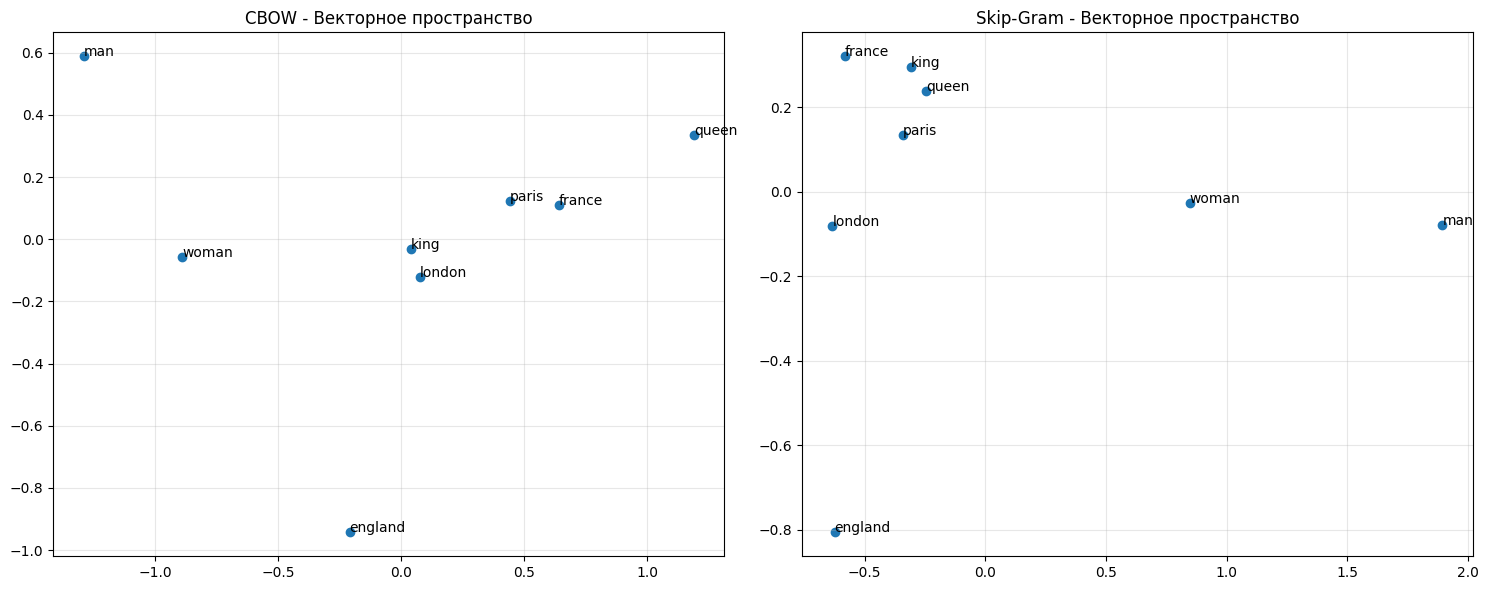

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_word_vectors(words, model, title, ax):
    """Визуализирует векторы слов в 2D пространстве"""
    vectors = []
    labels = []

    for word in words:
        try:
            vectors.append(model.wv[word])
            labels.append(word)
        except KeyError:
            print(f"Слово '{word}' не найдено")

    if len(vectors) < 2:
        print("Недостаточно слов для визуализации")
        return

    # Применяем PCA для уменьшения размерности до 2D
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Создаем scatter plot
    ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

    # Добавляем подписи
    for i, label in enumerate(labels):
        ax.annotate(label, (vectors_2d[i, 0], vectors_2d[i, 1]))

    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Создаем графики для сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Слова для визуализации
words_to_plot = ['king', 'queen', 'man', 'woman', 'paris', 'france', 'london', 'england']

plot_word_vectors(words_to_plot, cbow_model, "CBOW - Векторное пространство", ax1)
plot_word_vectors(words_to_plot, skipgram_model, "Skip-Gram - Векторное пространство", ax2)

plt.tight_layout()
plt.show()

CBOW - Тематические кластеры:


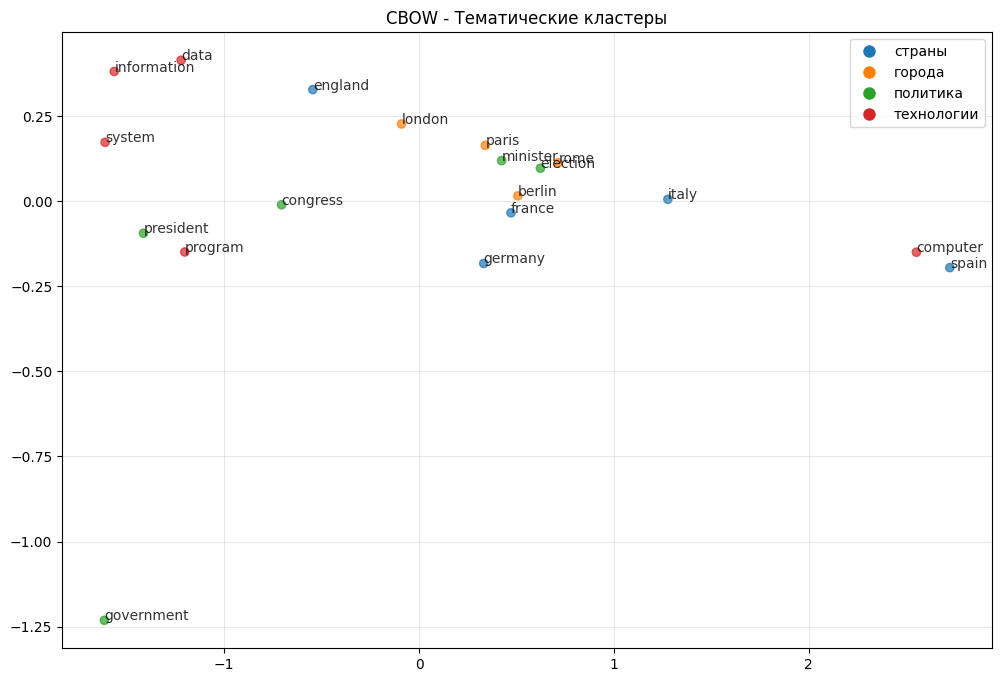

Skip-Gram - Тематические кластеры:


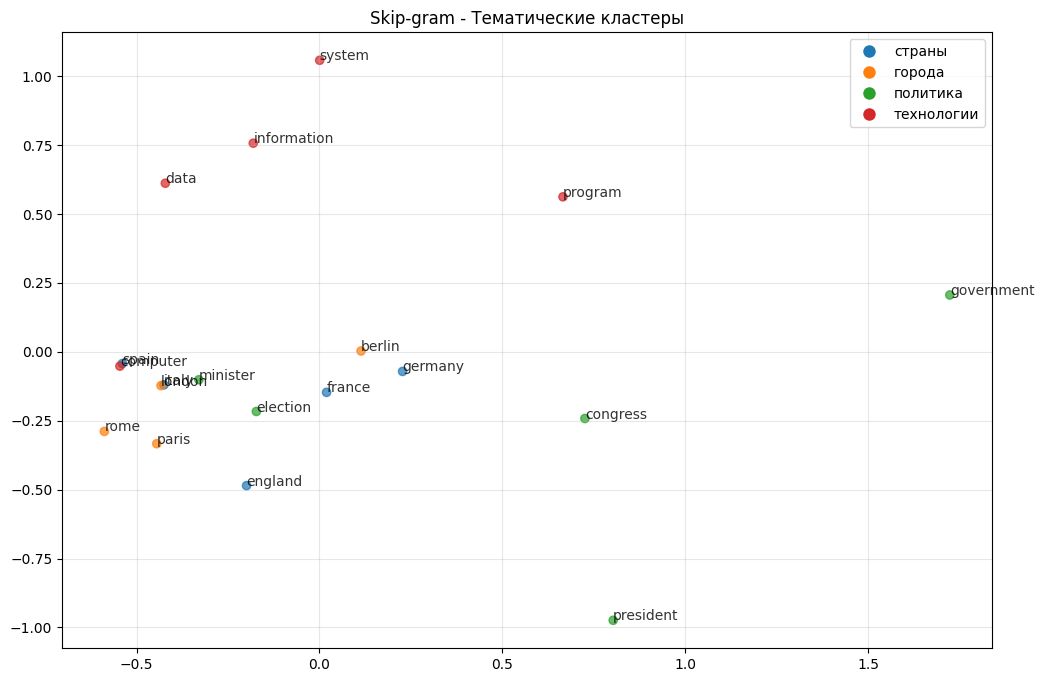

CBOW - Тематические кластеры:


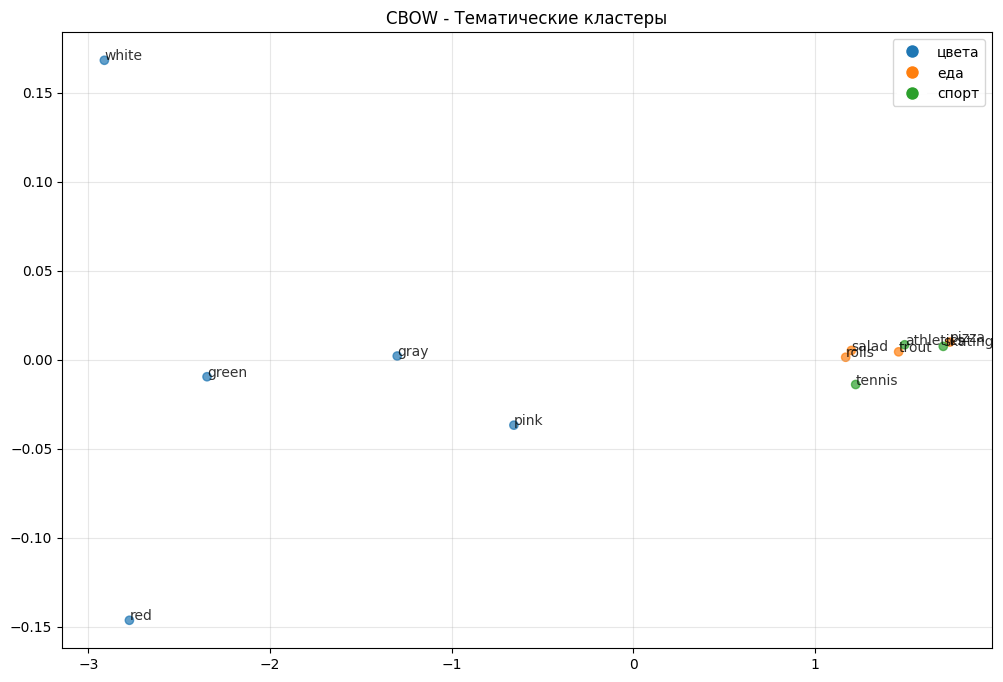

Skip-Gram - Тематические кластеры:


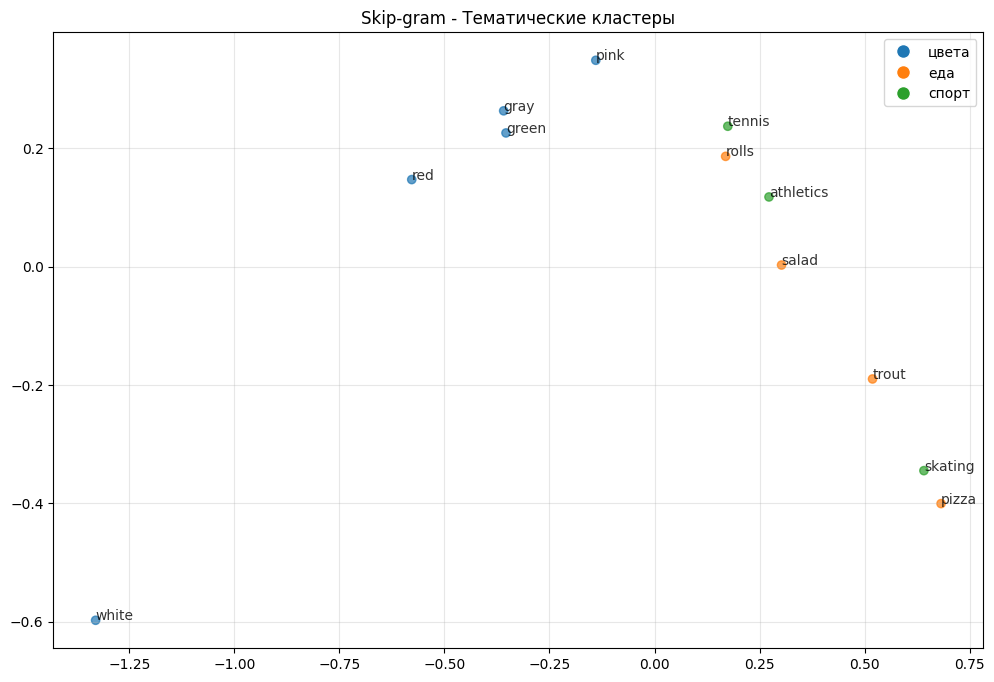

In [ ]:
# ЗАДАНИЕ: Создайте и визуализируйте тематические кластеры

def create_and_plot_clusters(word_groups, model, title):
    """Создает визуализацию для тематических групп слов"""
    all_words = []
    colors = []
    color_map = {}

    # Создаем список всех слов и их цветов
    for i, (theme, words) in enumerate(word_groups.items()):
        color_map[theme] = f'C{i}'  # автоматическое назначение цвета
        for word in words:
            all_words.append(word)
            colors.append(color_map[theme])

    # Получаем векторы
    vectors = []
    valid_words = []
    valid_colors = []

    for word, color in zip(all_words, colors):
        try:
            vectors.append(model.wv[word])
            valid_words.append(word)
            valid_colors.append(color)
        except KeyError:
            continue

    if len(vectors) < 2:
        print("Недостаточно слов для визуализации")

    # PCA для 2D
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Визуализация
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=valid_colors, alpha=0.7)

    # Подписи
    for i, word in enumerate(valid_words):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), alpha=0.8)

    # Легенда
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color, markersize=10, label=theme)
                      for theme, color in color_map.items()]
    plt.legend(handles=legend_elements)

    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()


# Пример тематических групп
thematic_groups = {
    'страны': ['france', 'germany', 'italy', 'spain', 'england'],
    'города': ['paris', 'london', 'rome', 'berlin', 'madrid'],
    'политика': ['government', 'president', 'election', 'minister', 'congress'],
    'технологии': ['computer', 'system', 'program', 'data', 'information']
}

# Создайте визуализации для обеих моделей
print("CBOW - Тематические кластеры:")
create_and_plot_clusters(thematic_groups, cbow_model, "CBOW - Тематические кластеры")

print("Skip-Gram - Тематические кластеры:")
create_and_plot_clusters(thematic_groups, skipgram_model, "Skip-gram - Тематические кластеры")


# Создайте свои тематические группы (например: еда, спорт, наука)
thematic_groups2 = {
    'цвета': ['white', 'red', 'green', 'pink', 'gray'],
    'еда': ['pasta', 'pizza', 'rolls', 'trout', 'salad'],
    'спорт': ['tennis', 'hockey', 'skating', 'archery', 'athletics']
}

# Создайте визуализации для обеих моделей
print("CBOW - Тематические кластеры:")
create_and_plot_clusters(thematic_groups2, cbow_model, "CBOW - Тематические кластеры")

print("Skip-Gram - Тематические кластеры:")
create_and_plot_clusters(thematic_groups2, skipgram_model, "Skip-gram - Тематические кластеры")

In [ ]:
# ЗАДАНИЕ: Проанализируйте влияние размера окна на качество векторов
import numpy as np

def test_window_sizes(window_sizes):
    """Тестирует разные размеры окон контекста"""
    results = []

    for window_size in window_sizes:
        print(f"Обучение модели с window={window_size}...")

        model = Word2Vec(
            sentences=processed_sentences,
            vector_size=100,
            window=window_size,
            min_count=2,
            workers=4,
            sg=1  # Skip-Gram
        )

        # Тестируем на нескольких парах
        test_pairs = [('king', 'queen'), ('man', 'woman'), ('paris', 'france')]
        similarities = []

        for word1, word2 in test_pairs:
            try:
                sim = model.wv.similarity(word1, word2)
                similarities.append(sim)
            except KeyError:
                similarities.append(0)

        avg_similarity = np.mean(similarities)
        results.append({
            'window_size': window_size,
            'avg_similarity': round(avg_similarity, 4),
            'vocab_size': len(model.wv.key_to_index)
        })

        print(f"  Среднее сходство: {avg_similarity:.4f}")

    return pd.DataFrame(results)

# Протестируйте разные размеры окон
window_sizes = [2, 5, 10]
results_df = test_window_sizes(window_sizes)
print("\nРезультаты тестирования размеров окон:")
print(results_df)

# Какой размер окна работает лучше?
# Протестируйте все остальные параметры

Обучение модели с window=2...
  Среднее сходство: 0.9172
Обучение модели с window=5...
  Среднее сходство: 0.8598
Обучение модели с window=10...
  Среднее сходство: 0.7582

Результаты тестирования размеров окон:
   window_size  avg_similarity  vocab_size
0            2          0.9172       26096
1            5          0.8598       26096
2           10          0.7582       26096


Лучше работает модель с window=2, так как у него самое высокое среднее сходство (0.9187).

Размер окна зависит от задачи:

- Синтаксис/морфология: окно 2-3

- Семантика/аналогии: окно 3-5

- Темы/документы: окно 5-10